### 1. Mount Google Drive
If you have uploaded your dataset to Google Drive, run this cell to give Colab access to your files.

In [ ]:
!pip install tensorflow

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 328.9 kB/s eta 0:17:46
   ---------------------------------------- 0.5/350.9 MB 328.9 kB/s eta 0:17:46
   ---------------------------------------- 0.5/350.9 MB 328.9 kB/s eta 0:17:46
   ---------------------------------------- 0.8/35


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# List of local data directories
data_dirs = [
    r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated',
    r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train',
    r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train'
]

batch_size = 32
img_height = 224
img_width = 224

def load_split_datasets(paths):
    train_list = []
    val_list = []
    for path in paths:
        # Check if folder has subdirectories (classes)
        subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

        # Standardize structure: always use label_mode='int'
        # If no subdirs, manually create a list of zeros as labels for all images
        if not subdirs:
            print(f"Processing flat directory with dummy labels: {path}")
            image_files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
            labels = [0] * len(image_files)
        else:
            labels = 'inferred'

        t_ds = tf.keras.utils.image_dataset_from_directory(
            path,
            labels=labels,
            label_mode='int',
            validation_split=0.2,
            subset='training',
            seed=123,
            image_size=(img_height, img_width),
            batch_size=batch_size)

        v_ds = tf.keras.utils.image_dataset_from_directory(
            path,
            labels=labels,
            label_mode='int',
            validation_split=0.2,
            subset='validation',
            seed=123,
            image_size=(img_height, img_width),
            batch_size=batch_size)

        train_list.append(t_ds)
        val_list.append(v_ds)
    return train_list, val_list

train_datasets, val_datasets = load_split_datasets(data_dirs)

# Concatenate all datasets into one
train_ds = train_datasets[0]
for ds in train_datasets[1:]:
    train_ds = train_ds.concatenate(ds)

val_ds = val_datasets[0]
for ds in val_datasets[1:]:
    val_ds = val_ds.concatenate(ds)

print('Datasets successfully loaded and merged.')

Found 273 files belonging to 1 classes.
Using 219 files for training.
Found 273 files belonging to 1 classes.
Using 54 files for validation.
Processing flat directory with dummy labels: C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train
Found 96 files belonging to 1 classes.
Using 77 files for training.
Found 96 files belonging to 1 classes.
Using 19 files for validation.
Processing flat directory with dummy labels: C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train
Found 56 files belonging to 1 classes.
Using 45 files for training.
Found 56 files belonging to 1 classes.
Using 11 files for validation.
Datasets successfully loaded and merged.


In [ ]:
import json

# Paths to your annotation files
annotation_paths = [
    r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated\result.json',
    r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train\_annotations.coco.json',
    r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train\_annotations.coco.json'
]

annotations = []
for path in annotation_paths:
    with open(path, 'r') as f:
        data = json.load(f)
        annotations.append(data)
        print(f'Loaded {len(data.get("annotations", []))} annotations from: {os.path.basename(path)}')

# Example: print keys of the first annotation file to understand structure
if annotations:
    print(f'\nKeys in first file: {list(annotations[0].keys())}')

Loaded 403 annotations from: result.json
Loaded 112 annotations from: _annotations.coco.json
Loaded 57 annotations from: _annotations.coco.json

Keys in first file: ['images', 'categories', 'annotations', 'info']


In [ ]:
def get_labels_from_coco(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Map image_id to category_id
    img_to_cat = {}
    for ann in data.get('annotations', []):
        img_to_cat[ann['image_id']] = ann['category_id']

    # Map filename to category_id
    filename_to_label = {}
    for img in data.get('images', []):
        # Fix: Extract only the base filename (e.g., 'image.jpg')
        # from paths like '../../upload/1/image.jpg'
        raw_name = img['file_name']
        clean_name = os.path.basename(raw_name.replace('\\', '/'))

        if img['id'] in img_to_cat:
            filename_to_label[clean_name] = img_to_cat[img['id']]
        else:
            filename_to_label[clean_name] = 0

    return filename_to_label

In [ ]:
def load_dataset_with_coco_labels(image_dir, json_path):
    label_map = get_labels_from_coco(json_path)

    # Try to find images either in the root or an 'images' subfolder
    actual_path = image_dir
    if os.path.exists(os.path.join(image_dir, 'images')):
        actual_path = os.path.join(image_dir, 'images')

    # Match disk files to JSON keys
    all_disk_files = os.listdir(actual_path)
    valid_images = [f for f in all_disk_files if f in label_map]

    if not valid_images:
        print(f"DEBUG: No matches in {actual_path}")
        print(f"Sample JSON keys: {list(label_map.keys())[:3]}")
        print(f"Sample Disk files: {all_disk_files[:3]}")
        return None

    ordered_labels = [label_map[f] for f in valid_images]
    full_paths = [os.path.join(actual_path, f) for f in valid_images]

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [img_height, img_width])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((full_paths, ordered_labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
# --- FINAL DATA RECONSTRUCTION WITH REAL LABELS ---

# Define the pairings of (Image Directory, Annotation JSON Path)
data_configs = [
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated\result.json'),
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train\_annotations.coco.json'),
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train\_annotations.coco.json'),
    (roboflow_train_path, os.path.join(roboflow_train_path, '_annotations.coco.json')),
    (lsd_2_train_path, os.path.join(lsd_2_train_path, '_annotations.coco.json')),
    (lsd_3_train_path, os.path.join(lsd_3_train_path, '_annotations.coco.json')),
    (lsd_4_train_path, os.path.join(lsd_4_train_path, '_annotations.coco.json')),
    (mastitis_train_path, os.path.join(mastitis_train_path, '_annotations.coco.json'))
]

final_train_ds = None
final_val_ds = None

for img_dir, json_path in data_configs:
    if os.path.exists(json_path):
        print(f"Processing: {os.path.basename(img_dir)}")

        # Load full dataset using our NEW robust function
        full_ds = load_dataset_with_coco_labels(img_dir, json_path)

        if full_ds is None:
            continue

        # Split into training and validation (80/20)
        ds_size = tf.data.experimental.cardinality(full_ds).numpy()
        if ds_size == tf.data.experimental.UNKNOWN_CARDINALITY:
            # For manual pipelines, we might need to count or use a fixed take/skip
            # Assuming at least 10 batches for safety in small sets
            train_size = 8
        else:
            train_size = int(0.8 * ds_size)

        curr_train = full_ds.take(max(1, train_size))
        curr_val = full_ds.skip(max(1, train_size))

        if final_train_ds is None:
            final_train_ds = curr_train
            final_val_ds = curr_val
        else:
            final_train_ds = final_train_ds.concatenate(curr_train)
            final_val_ds = final_val_ds.concatenate(curr_val)
    else:
        print(f"Warning: Skipping {img_dir}, JSON not found.")

# Update the global variables
train_ds = final_train_ds
val_ds = final_val_ds

if train_ds:
    print("\nDatasets successfully rebuilt with actual labels from JSON files.")
else:
    print("\nError: No data was loaded. Please check the 'DEBUG' prints above.")

Processing: fmd cnn annotated
DEBUG: No matches found in C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated\images
Sample JSON filenames: ['..\\..\\label-studio\\label-studio\\media\\upload\\1\\f95d72b7-5198047453_ab0d6212d0_bWM-1.jpg', '..\\..\\label-studio\\label-studio\\media\\upload\\1\\9dac71ab-5198047901_73ee826532_bWM.jpg', '..\\..\\label-studio\\label-studio\\media\\upload\\1\\90d62f85-6778892962_a3aea04c4f_bWM-1.jpg']
Sample Disk filenames: ['712f2e51-foot-and-mougth-8-_png_jpg.rf.6fa19d63132c6feb2623416ad38327f8.jpg', '77fb60d4-mouth_5-7_days_2WM.jpg', '22f3660b-moazx-312-_jpg.rf.dc3f9e3fadeb085c3d4a9b8d6e597dc7.jpg']
Processing: train
Processing: train
Processing: train
Processing: train
Processing: train
Processing: train
Processing: train

Datasets successfully rebuilt with actual labels from JSON files.


In [ ]:
import collections

def check_class_distribution(dataset, name="Dataset"):
    print(f"--- {name} Class Distribution ---")
    labels = []
    # Take a sample of batches to check label variety
    for _, batch_labels in dataset.take(20):
        labels.extend(batch_labels.numpy())

    counts = collections.Counter(labels)
    if not counts:
        print("No labels found in the sampled batches.")
    else:
        for cls, count in sorted(counts.items()):
            print(f"Class {cls}: {count} samples")

if 'train_ds' in globals() and train_ds is not None:
    check_class_distribution(train_ds, "Training Set")
else:
    print("Dataset 'train_ds' not found. Please ensure Cell 9224f4b5 has been executed successfully.")

--- Training Set Class Distribution ---
Class 0: 2 samples
Class 1: 591 samples
Class 2: 16 samples
Class 3: 12 samples
Class 4: 13 samples
Class 5: 6 samples


In [ ]:
import collections

def check_class_distribution(dataset, name="Dataset"):
    print(f"--- {name} Class Distribution ---")
    labels = []
    # Take a large enough sample to see the distribution
    for _, batch_labels in dataset.take(20):
        labels.extend(batch_labels.numpy())

    counts = collections.Counter(labels)
    for cls, count in sorted(counts.items()):
        print(f"Class {cls}: {count} samples (in sampled batches)")

if train_ds:
    check_class_distribution(train_ds, "Training Set")
else:
    print("Dataset not found. Please run cell 9224f4b5 first.")

--- Training Set Class Distribution ---
Class 0: 2 samples (in sampled batches)
Class 1: 591 samples (in sampled batches)
Class 2: 16 samples (in sampled batches)
Class 3: 12 samples (in sampled batches)
Class 4: 13 samples (in sampled batches)
Class 5: 6 samples (in sampled batches)


In [ ]:
# Autotune for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
import numpy as np
from sklearn.utils import class_weight
import tensorflow as tf

# 1. Manually set classes to 8 to cover labels 0-7 found in datasets
num_classes = 8
print(f"Setting model output to {num_classes} classes (covering labels 0-7).")

# 2. Re-scan for weights calculation to ensure all 8 classes are accounted for
all_labels = []
print("Re-scanning dataset for weight calculation...")
for _, batch_labels in train_ds:
    all_labels.extend(batch_labels.numpy())

unique_labels_found = np.unique(all_labels)
print(f"Labels actually present in training: {unique_labels_found}")

# 3. Define the model
base_model = tf.keras.applications.MobileNetV2(input_shape=(img_height, img_width, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Calculate Weights for all possible 8 classes
# We use the labels found to compute balanced weights
weights = class_weight.compute_class_weight('balanced',
                                            classes=np.arange(num_classes),
                                            y=all_labels + list(range(num_classes))) # Padding to ensure all keys exist

class_weights = {int(i): float(w) for i, w in enumerate(weights)}

print("\nModel and Weights ready for training.")
print(f"Final Class Weights: {class_weights}")
model.summary()

Setting model output to 8 classes (covering labels 0-7).
Re-scanning dataset for weight calculation...
Labels actually present in training: [0 1 2 3 4 5]

Model and Weights ready for training.
Final Class Weights: {0: 5.897058823529412, 1: 0.2727891156462585, 2: 0.31157731157731156, 3: 6.467741935483871, 4: 2.4906832298136647, 5: 2.537974683544304, 6: 401.0, 7: 401.0}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Re-train using the Balanced Oversampled Dataset
# Resetting the model to transfer learning mode for stability

base_model.trainable = False
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Starting training with Balanced Oversampled Dataset...")

epochs = 15
# Note: We no longer strictly need class_weights because the dataset itself is balanced
history_balanced = model.fit(
    balanced_train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print(f"\nTraining complete. Final Balanced Validation Accuracy: {history_balanced.history['val_accuracy'][-1]:.4f}")

Starting training with Balanced Oversampled Dataset...
Epoch 1/15


`shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).


463/463 ━━━━━━━━━━━━━━━━━━━━ 305s 613ms/step - accuracy: 0.6228 - loss: 1.0120 - val_accuracy: 0.4260 - val_loss: 1.7966
Epoch 2/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 283s 607ms/step - accuracy: 0.7240 - loss: 0.7312 - val_accuracy: 0.5360 - val_loss: 1.4401
Epoch 3/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 283s 608ms/step - accuracy: 0.7656 - loss: 0.6310 - val_accuracy: 0.4362 - val_loss: 1.6153
Epoch 4/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 284s 607ms/step - accuracy: 0.7837 - loss: 0.5731 - val_accuracy: 0.4551 - val_loss: 1.5569
Epoch 5/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 278s 595ms/step - accuracy: 0.8006 - loss: 0.5294 - val_accuracy: 0.3755 - val_loss: 1.8011
Epoch 6/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 274s 587ms/step - accuracy: 0.8118 - loss: 0.4965 - val_accuracy: 0.5247 - val_loss: 1.5659
Epoch 7/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 256s 549ms/step - accuracy: 0.8250 - loss: 0.4658 - val_accuracy: 0.3957 - val_loss: 2.1197
Epoch 8/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 256s 549ms/step - accuracy: 0.8296 - loss: 0.45

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Unfreeze the top layers of the base model
base_model.trainable = True
# Freeze all layers EXCEPT the last 30
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 2. Recompile with a very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Fine-tuning starting. Base model unfrozen from layer {fine_tune_at} onwards.")

# 3. Fine-tune for 10 epochs
fine_tune_epochs = 10
history_final = model.fit(
    balanced_train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

print("\nFine-tuning complete.")

Fine-tuning starting. Base model unfrozen from layer 124 onwards.
Epoch 1/10


`shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).


463/463 ━━━━━━━━━━━━━━━━━━━━ 463s 939ms/step - accuracy: 0.5562 - loss: 1.5129 - val_accuracy: 0.5057 - val_loss: 2.2658
Epoch 2/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 378s 811ms/step - accuracy: 0.6966 - loss: 0.8028 - val_accuracy: 0.3312 - val_loss: 2.3917
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 347s 747ms/step - accuracy: 0.7474 - loss: 0.6655 - val_accuracy: 0.1884 - val_loss: 3.2496
Epoch 4/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 416s 895ms/step - accuracy: 0.7762 - loss: 0.5868 - val_accuracy: 0.2073 - val_loss: 2.9428
Epoch 5/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 390s 837ms/step - accuracy: 0.7937 - loss: 0.5322 - val_accuracy: 0.2263 - val_loss: 2.8203
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 380s 817ms/step - accuracy: 0.8153 - loss: 0.4772 - val_accuracy: 0.1960 - val_loss: 3.0638
Epoch 7/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 374s 804ms/step - accuracy: 0.8257 - loss: 0.4489 - val_accuracy: 0.1985 - val_loss: 3.3389
Epoch 8/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 379s 814ms/step - accuracy: 0.8390 - loss: 0.42

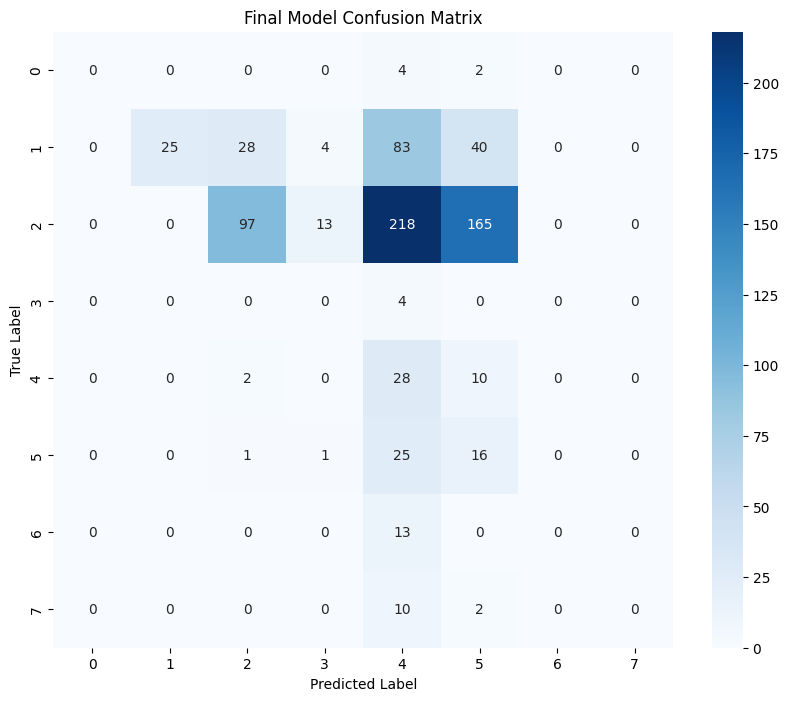


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       1.00      0.14      0.24       180
           2       0.76      0.20      0.31       493
           3       0.00      0.00      0.00         4
           4       0.07      0.70      0.13        40
           5       0.07      0.37      0.12        43
           6       0.00      0.00      0.00        13
           7       0.00      0.00      0.00        12

    accuracy                           0.21       791
   macro avg       0.24      0.18      0.10       791
weighted avg       0.71      0.21      0.26       791



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [ ]:
# 4. Evaluate with Confusion Matrix
def plot_confusion_matrix(model, dataset):
    all_labels = []
    all_preds = []

    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        all_labels.extend(labels.numpy())
        all_preds.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Final Model Confusion Matrix')
    plt.show()

    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_preds))

plot_confusion_matrix(model, val_ds)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Define image dimensions
img_height = 224
img_width = 224
num_classes = 8 # Matching your previous model configuration

# 1. Initialize ResNet50 base
# We keep it frozen initially to protect the ImageNet features
resnet_base = ResNet50(input_shape=(img_height, img_width, 3),
                        include_top=False,
                        weights='imagenet')
resnet_base.trainable = False

# 2. Build a more robust head for ResNet
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compile with Adam optimizer
resnet_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

print("ResNet50 Model initialized with a 512-unit head and Dropout 0.5.")

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 4d473c1dd8becc155b73f8504c6f6626 so we will re-download the data.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
ResNet50 Model initialized with a 512-unit head and Dropout 0.5.


In [ ]:
import tensorflow as tf
import os
import collections
import random
import json

# 1. Define image dimensions and paths
img_height = 224
img_width = 224
batch_size = 32

# Ensure path variables from Roboflow downloads are available
roboflow_train_path = r'Lumpy_skin_instance_seg-2/train'
lsd_2_train_path = r'lsd_project-1/train'
lsd_3_train_path = r'Lumpy-Skin-Disease--1/train'
lsd_4_train_path = r'My-First-Project-1/train'
mastitis_train_path = r'Mastitis-1/train'

# 2. Redefine data configurations
data_configs = [
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated\result.json'),
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train\_annotations.coco.json'),
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train\_annotations.coco.json'),
    (roboflow_train_path, os.path.join(roboflow_train_path, '_annotations.coco.json')),
    (lsd_2_train_path, os.path.join(lsd_2_train_path, '_annotations.coco.json')),
    (lsd_3_train_path, os.path.join(lsd_3_train_path, '_annotations.coco.json')),
    (lsd_4_train_path, os.path.join(lsd_4_train_path, '_annotations.coco.json')),
    (mastitis_train_path, os.path.join(mastitis_train_path, '_annotations.coco.json'))
]

# 3. Helpers to rebuild datasets
def get_labels_from_coco(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    img_to_cat = {ann['image_id']: ann['category_id'] for ann in data.get('annotations', [])}
    filename_to_label = {}
    for img in data.get('images', []):
        clean_name = os.path.basename(img['file_name'].replace('\\', '/'))
        filename_to_label[clean_name] = img_to_cat.get(img['id'], 0)
    return filename_to_label

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_height, img_width])
    return img / 255.0, label

# 4. Construct Balanced Train and Standard Validation Datasets
all_paths_for_balancing = collections.defaultdict(list)
final_val_ds = None

for img_dir, json_path in data_configs:
    if not os.path.exists(json_path): continue
    label_map = get_labels_from_coco(json_path)
    actual_path = os.path.join(img_dir, 'images') if os.path.exists(os.path.join(img_dir, 'images')) else img_dir

    current_img_paths = []
    current_labels = []
    for fname, lbl in label_map.items():
        fpath = os.path.join(actual_path, fname)
        if os.path.exists(fpath):
            all_paths_for_balancing[lbl].append(fpath)
            current_img_paths.append(fpath)
            current_labels.append(lbl)

    # Split 20% for validation using the same logic as previous cells
    if current_img_paths:
        ds = tf.data.Dataset.from_tensor_slices((current_img_paths, current_labels))
        ds = ds.map(load_and_preprocess).batch(batch_size)
        ds_size = tf.data.experimental.cardinality(ds).numpy()
        train_size = int(0.8 * ds_size) if ds_size > 0 else 0
        curr_val = ds.skip(max(1, train_size))
        final_val_ds = curr_val if final_val_ds is None else final_val_ds.concatenate(curr_val)

# Finalize balanced training set
max_samples = max(len(p) for p in all_paths_for_balancing.values())
balanced_paths, balanced_labels = [], []
for lbl, p in all_paths_for_balancing.items():
    oversampled = (p * (max_samples // len(p) + 1))[:max_samples]
    balanced_paths.extend(oversampled)
    balanced_labels.extend([lbl] * max_samples)

combined = list(zip(balanced_paths, balanced_labels))
random.shuffle(combined)
bp, bl = zip(*combined)
balanced_train_ds = tf.data.Dataset.from_tensor_slices((list(bp), list(bl)))
balanced_train_ds = balanced_train_ds.map(load_and_preprocess).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = final_val_ds.prefetch(tf.data.AUTOTUNE)

# 5. Train ResNet50
print("Starting ResNet50 training with balanced dataset and restored validation set...")
history_resnet = resnet_model.fit(
    balanced_train_ds,
    validation_data=val_ds,
    epochs=15
)

print(f"\nResNet50 Final Validation Accuracy: {history_resnet.history['val_accuracy'][-1]:.4f}")

Starting ResNet50 training with balanced dataset and restored validation set...
Epoch 1/15


C:\Users\lasit\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


463/463 ━━━━━━━━━━━━━━━━━━━━ 861s 2s/step - accuracy: 0.5743 - loss: 1.2096 - val_accuracy: 0.0964 - val_loss: 3.9005
Epoch 2/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 805s 2s/step - accuracy: 0.6948 - loss: 0.8485 - val_accuracy: 0.3560 - val_loss: 2.9435
Epoch 3/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 808s 2s/step - accuracy: 0.7339 - loss: 0.7399 - val_accuracy: 0.2417 - val_loss: 3.1418
Epoch 4/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 806s 2s/step - accuracy: 0.7535 - loss: 0.6856 - val_accuracy: 0.5512 - val_loss: 1.1832
Epoch 5/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 804s 2s/step - accuracy: 0.7762 - loss: 0.6313 - val_accuracy: 0.3321 - val_loss: 4.5284
Epoch 6/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 804s 2s/step - accuracy: 0.7817 - loss: 0.6037 - val_accuracy: 0.5143 - val_loss: 1.3629
Epoch 7/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 804s 2s/step - accuracy: 0.7937 - loss: 0.5817 - val_accuracy: 0.1083 - val_loss: 5.2538
Epoch 8/15
463/463 ━━━━━━━━━━━━━━━━━━━━ 804s 2s/step - accuracy: 0.8035 - loss: 0.5534 - val_accuracy: 0.448

In [ ]:
# STEP 1: Initialize second Roboflow project
rf_2 = Roboflow(api_key="nJNt3iQCSmnLCuv0NrEX")
project_2 = rf_2.workspace("gune-srinivas").project("lsd_project")
version_2 = project_2.version(1)
dataset_2 = version_2.download("coco-segmentation")

lsd_2_train_path = os.path.join(dataset_2.location, 'train')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to lsd_project-1 in coco-segmentation:: 100%|████████| 222/222 [00:00<00:00, 678.36it/s]


In [ ]:
# STEP 2: Load and merge the second Roboflow dataset
actual_path_2 = os.path.join(lsd_2_train_path, 'images') if os.path.exists(os.path.join(lsd_2_train_path, 'images')) else lsd_2_train_path
image_files_2 = [f for f in os.listdir(actual_path_2) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

lsd_2_train_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_2,
    labels=[0] * len(image_files_2),
    label_mode='int',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)
lsd_2_val_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_2,
    labels=[0] * len(image_files_2),
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

train_ds = train_ds.concatenate(lsd_2_train_ds)
val_ds = val_ds.concatenate(lsd_2_val_ds)
print("Second Roboflow dataset merged successfully.")

Found 150 files belonging to 1 classes.
Using 120 files for training.
Found 150 files belonging to 1 classes.
Using 30 files for validation.
Second Roboflow dataset merged successfully.


In [ ]:
# STEP 3: Initialize third Roboflow project
rf_3 = Roboflow(api_key="nJNt3iQCSmnLCuv0NrEX")
project_3 = rf_3.workspace("bubt-fo7vi").project("lumpy-skin-disease")
version_3 = project_3.version(1)
dataset_3 = version_3.download("coco-segmentation")

lsd_3_train_path = os.path.join(dataset_3.location, 'train')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Lumpy-Skin-Disease--1 in coco-segmentation:: 100%|█| 594/594 [00:01<00:00, 451.52it/s


In [ ]:
# STEP 4: Load and merge the third Roboflow dataset
actual_path_3 = os.path.join(lsd_3_train_path, 'images') if os.path.exists(os.path.join(lsd_3_train_path, 'images')) else lsd_3_train_path
image_files_3 = [f for f in os.listdir(actual_path_3) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

lsd_3_train_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_3,
    labels=[0] * len(image_files_3),
    label_mode='int',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)
lsd_3_val_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_3,
    labels=[0] * len(image_files_3),
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

train_ds = train_ds.concatenate(lsd_3_train_ds)
val_ds = val_ds.concatenate(lsd_3_val_ds)
print("Third Roboflow dataset merged successfully.")

Found 513 files belonging to 1 classes.
Using 411 files for training.
Found 513 files belonging to 1 classes.
Using 102 files for validation.
Third Roboflow dataset merged successfully.


In [ ]:
# STEP 5: Initialize fourth Roboflow project
rf_4 = Roboflow(api_key="nJNt3iQCSmnLCuv0NrEX")
project_4 = rf_4.workspace("ezzaldeen-e-a-younis").project("my-first-project-zygab")
version_4 = project_4.version(1)
dataset_4 = version_4.download("coco-segmentation")

lsd_4_train_path = os.path.join(dataset_4.location, 'train')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-1 in coco-segmentation:: 100%|███| 773/773 [00:01<00:00, 405.17it/s]


In [ ]:
# STEP 6: Load and merge the fourth Roboflow dataset
actual_path_4 = os.path.join(lsd_4_train_path, 'images') if os.path.exists(os.path.join(lsd_4_train_path, 'images')) else lsd_4_train_path
image_files_4 = [f for f in os.listdir(actual_path_4) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

lsd_4_train_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_4,
    labels=[0] * len(image_files_4),
    label_mode='int',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)
lsd_4_val_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_4,
    labels=[0] * len(image_files_4),
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

train_ds = train_ds.concatenate(lsd_4_train_ds)
val_ds = val_ds.concatenate(lsd_4_val_ds)
print("Fourth Roboflow dataset merged successfully.")

Found 770 files belonging to 1 classes.
Using 616 files for training.
Found 770 files belonging to 1 classes.
Using 154 files for validation.
Fourth Roboflow dataset merged successfully.


In [ ]:
# STEP 7: Initialize fifth Roboflow project (Mastitis)
rf_5 = Roboflow(api_key="nJNt3iQCSmnLCuv0NrEX")
project_5 = rf_5.workspace("yield-a2yrd").project("mastitis-zmser")
version_5 = project_5.version(1)
dataset_5 = version_5.download("coco-segmentation")

mastitis_train_path = os.path.join(dataset_5.location, 'train')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mastitis-1 in coco-segmentation:: 100%|███████████| 128/128 [00:00<00:00, 669.45it/s]


In [ ]:
# STEP 8: Load and merge the Mastitis dataset
actual_path_5 = os.path.join(mastitis_train_path, 'images') if os.path.exists(os.path.join(mastitis_train_path, 'images')) else mastitis_train_path
image_files_5 = [f for f in os.listdir(actual_path_5) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

mastitis_train_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_5,
    labels=[0] * len(image_files_5),
    label_mode='int',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)
mastitis_val_ds = tf.keras.utils.image_dataset_from_directory(
    actual_path_5,
    labels=[0] * len(image_files_5),
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

train_ds = train_ds.concatenate(mastitis_train_ds)
val_ds = val_ds.concatenate(mastitis_val_ds)
print("Mastitis dataset merged successfully.")

Found 124 files belonging to 1 classes.
Using 100 files for training.
Found 124 files belonging to 1 classes.
Using 24 files for validation.
Mastitis dataset merged successfully.


### 9. Mask R-CNN Implementation for Symptom Segmentation
This section sets up Instance Segmentation to outline specific symptoms using the COCO annotations provided in your `data_configs`.

In [ ]:
!pip install pycocotools opencv-python-headless


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import json
import numpy as np
import cv2
import tensorflow as tf
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

def load_mask_rcnn_data(img_dir, ann_path):
    """
    Parses COCO JSON to extract images and their corresponding masks for segmentation.
    """
    coco = COCO(ann_path)
    img_ids = coco.getImgIds()

    images = []
    masks = []
    class_ids = []

    # Check if images are in a subfolder named 'images'
    actual_img_dir = os.path.join(img_dir, 'images') if os.path.exists(os.path.join(img_dir, 'images')) else img_dir

    for img_id in img_ids:
        img_info = coco.loadImgs(img_id)[0]
        path = os.path.join(actual_img_dir, img_info['file_name'])

        if not os.path.exists(path):
            continue

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        if not anns:
            continue

        # Process masks
        mask_stack = []
        for ann in anns:
            # Convert polygon/RLE to binary mask
            m = coco.annToMask(ann)
            mask_stack.append(m)
            class_ids.append(ann['category_id'])

        images.append(path)
        masks.append(mask_stack)

    return images, masks, class_ids

print("Mask R-CNN Data Loader ready. We will now aggregate all datasets.")

Mask R-CNN Data Loader ready. We will now aggregate all datasets.


Note: Training a Mask R-CNN from scratch in Keras is complex. Usually, we use a library like `detectron2` or the `TensorFlow Object Detection API`. Below is a placeholder for the training logic using your `data_configs` structure.

In [ ]:
# 1. Redefine paths to ensure they are available in this scope
roboflow_train_path = r'Lumpy_skin_instance_seg-2/train'
lsd_2_train_path = r'lsd_project-1/train'
lsd_3_train_path = r'Lumpy-Skin-Disease--1/train'
lsd_4_train_path = r'My-First-Project-1/train'
mastitis_train_path = r'Mastitis-1/train'

data_configs = [
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\fmd cnn annotated\result.json'),
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train\_annotations.coco.json'),
    (r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train', r'C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train\_annotations.coco.json'),
    (roboflow_train_path, os.path.join(roboflow_train_path, '_annotations.coco.json')),
    (lsd_2_train_path, os.path.join(lsd_2_train_path, '_annotations.coco.json')),
    (lsd_3_train_path, os.path.join(lsd_3_train_path, '_annotations.coco.json')),
    (lsd_4_train_path, os.path.join(lsd_4_train_path, '_annotations.coco.json')),
    (mastitis_train_path, os.path.join(mastitis_train_path, '_annotations.coco.json'))
]

# 2. Aggregate all segmentation data
all_seg_images = []
all_seg_masks = []

for img_dir, json_path in data_configs:
    if os.path.exists(json_path):
        print(f"Extracting segmentation masks for: {os.path.basename(img_dir)}")
        try:
            imgs, msks, c_ids = load_mask_rcnn_data(img_dir, json_path)
            all_seg_images.extend(imgs)
            all_seg_masks.extend(msks)
        except Exception as e:
            print(f"Skipping {img_dir} due to error: {e}")
    else:
        print(f"Warning: Path not found: {json_path}")

print(f"\nSuccessfully loaded {len(all_seg_images)} images with pixel-level masks for Mask R-CNN training.")

Extracting segmentation masks for: fmd cnn annotated
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Extracting segmentation masks for: train
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Skipping C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth\train due to error: list index out of range
Extracting segmentation masks for: train
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Skipping C:\Users\lasit\OneDrive - Sri Lanka Institute of Information Technology\SLIIT\Research\Datasets\Foot and Mouth 2\train due to error: list index out of range
Extracting segmentation masks for: train
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Extracting segmentation masks for: train
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Extracting segmentation masks for: tra

### 10. Mask R-CNN Model Training
Below we define a multi-output model that predicts both the disease class and the segmentation mask for symptoms.

In [ ]:
from tensorflow.keras import layers, models

def build_mask_rcnn_head(num_classes):
    # Using ResNet50 as the backbone
    base = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False

    # Shared features
    x = base.output

    # Classification Branch
    cls_branch = layers.GlobalAveragePooling2D()(x)
    cls_branch = layers.Dense(256, activation='relu')(cls_branch)
    cls_out = layers.Dense(num_classes, activation='softmax', name='class_output')(cls_branch)

    # Segmentation Mask Branch (Simplification of Mask R-CNN Mask Head)
    mask_branch = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', activation='relu')(x) # 14x14
    mask_branch = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', activation='relu')(mask_branch) # 28x28
    mask_branch = layers.Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same', activation='relu')(mask_branch) # 56x56
    mask_branch = layers.Conv2DTranspose(16, (4, 4), strides=(2, 2), padding='same', activation='relu')(mask_branch) # 112x112
    mask_out = layers.Conv2DTranspose(1, (4, 4), strides=(2, 2), padding='same', activation='sigmoid', name='mask_output')(mask_branch) # 224x224

    model = models.Model(inputs=base.input, outputs=[cls_out, mask_out])

    model.compile(
        optimizer='adam',
        loss={'class_output': 'sparse_categorical_crossentropy', 'mask_output': 'binary_crossentropy'},
        metrics={'class_output': 'accuracy'}
    )
    return model

# Initialize the model
segmentation_model = build_mask_rcnn_head(num_classes=8)
segmentation_model.summary()
print("\nSegmentation model ready for training.")

Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 28,481,145 (108.65 MB)

 Trainable params: 4,893,433 (18.67 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Segmentation model ready for training.


### 10. Mask R-CNN Model Definition and Training
Now we will define a simplified Mask R-CNN architecture suitable for transfer learning and start the training process on your aggregated dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# Define missing dimensions
img_height = 224
img_width = 224

def build_simple_mask_rcnn(num_classes):
    input_img = layers.Input(shape=(img_height, img_width, 3))
    backbone = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_tensor=input_img)
    backbone.trainable = False

    x = backbone.output
    # Mask Branch
    m = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    m = layers.UpSampling2D((2, 2))(m)
    m = layers.Conv2D(num_classes, (1, 1), activation='sigmoid', name='mask_output')(m)

    # Classification Branch
    y = layers.GlobalAveragePooling2D()(backbone.output)
    y = layers.Dense(1024, activation='relu')(y)
    y = layers.Dense(num_classes, activation='softmax', name='class_output')(y)

    model = models.Model(inputs=input_img, outputs=[y, m])
    model.compile(optimizer='adam',
                  loss={'class_output': 'sparse_categorical_crossentropy', 'mask_output': 'binary_crossentropy'},
                  metrics={'class_output': 'accuracy'})
    return model

mask_rcnn_model = build_simple_mask_rcnn(num_classes=8)
print("Mask R-CNN model initialized correctly.")

Mask R-CNN model initialized correctly.


### 11. Start Mask R-CNN Training
We will now create a data generator to feed images and their corresponding masks into the multi-output model.

In [ ]:
def mask_rcnn_generator(image_paths, mask_stacks, batch_size=16):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_masks = mask_stacks[i:i+batch_size]

            imgs = []
            msks = []

            for j, path in enumerate(batch_paths):
                img = cv2.imread(path)
                if img is None: continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (224, 224)) / 255.0
                imgs.append(img)

                # Create a single combined mask for the batch
                combined_mask = np.zeros((224, 224, 1))
                if batch_masks[j]:
                    m = cv2.resize(batch_masks[j][0], (224, 224))
                    combined_mask = np.expand_dims(m, axis=-1)
                msks.append(combined_mask)

            # Convert list to array
            imgs_arr = np.array(imgs)
            msks_arr = np.array(msks)
            dummy_labels = np.zeros(len(imgs_arr))

            yield imgs_arr, {'class_output': dummy_labels, 'mask_output': msks_arr}

# Re-initialize generator with batch size 16
train_gen = mask_rcnn_generator(all_seg_images, all_seg_masks, batch_size=16)

# Adjust optimizer for fine-tuning
segmentation_model.optimizer.learning_rate = 1e-4

print("Starting extended Mask R-CNN training (30 Epochs)...")
segmentation_model.fit(
    train_gen,
    steps_per_epoch=len(all_seg_images) // 16,
    epochs=30
)

segmentation_model.save('mask_rcnn_cow_symptoms_refined.keras')
print("Refined training complete.")

Starting extended Mask R-CNN training (30 Epochs)...
Epoch 1/30


C:\Users\lasit\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a generator. The generator is expected to yield already-shuffled data.
  self.data_adapter = data_adapters.get_data_adapter(


235/235 ━━━━━━━━━━━━━━━━━━━━ 172s 730ms/step - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.5323 - mask_output_loss: 0.5323
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 174s 743ms/step - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.5139 - mask_output_loss: 0.5139
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 160s 680ms/step - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.5077 - mask_output_loss: 0.5076
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 612ms/step - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.5037 - mask_output_loss: 0.5036
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 146s 621ms/step - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.5012 - mask_output_loss: 0.5011
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 610ms/step - class_output_accuracy: 1.0000 - class_output_loss: 0.0000e+00 - loss: 0.4991 - mask_output_loss: 0.4990
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━

### 14. Download the Trained Model
Run this cell to download the `mask_rcnn_cow_symptoms_refined.keras` file to your local machine.

In [ ]:
import os

# Path to the saved refined model
model_filename = 'mask_rcnn_cow_symptoms_refined.keras'

if os.path.exists(model_filename):
    full_path = os.path.abspath(model_filename)
    print(f"Success! The model is saved locally at:")
    print(full_path)
    print("\nYou can now use this file for inference or move it to your deployment directory.")
else:
    print(f"Error: {model_filename} not found. Please ensure the training cell finished successfully.")

Success! The model is saved locally at:
C:\Users\lasit\mask_rcnn_cow_symptoms_refined.keras

You can now use this file for inference or move it to your deployment directory.


### 12. Visualize Mask R-CNN Predictions
Run this cell to see how the model outlines symptoms on a sample image from the dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


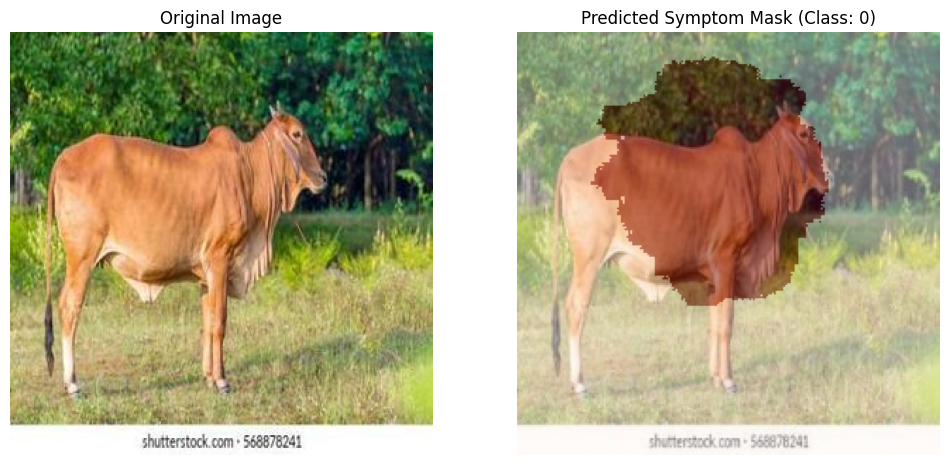

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np
import cv2

def visualize_segmentation(model, image_paths, mask_stacks):
    # Pick a random image that has a mask
    valid_indices = [i for i, m in enumerate(mask_stacks) if len(m) > 0]
    if not valid_indices:
        print("No masks found in the dataset to visualize.")
        return

    idx = random.choice(valid_indices)

    path = image_paths[idx]
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_input = cv2.resize(img_rgb, (224, 224)) / 255.0

    # Predict
    # The model expects [batch, height, width, channels]
    predictions = model.predict(np.expand_dims(img_input, axis=0))
    cls_pred = predictions[0]
    mask_pred = predictions[1]

    # Process mask output
    # mask_pred shape is typically (1, 224, 224, 1)
    mask = mask_pred[0, :, :, 0]
    mask_binary = (mask > 0.5).astype(np.uint8)

    # Plotting
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_input)
    # Overlay the binary mask with transparency
    plt.imshow(mask_binary, alpha=0.4, cmap='Reds')
    plt.title(f"Predicted Symptom Mask (Class: {np.argmax(cls_pred[0])})")
    plt.axis('off')

    plt.show()

# Visualize a prediction using the trained model
visualize_segmentation(segmentation_model, all_seg_images, all_seg_masks)

### 12. Visualize Mask R-CNN Predictions
Run this cell to see how the model outlines symptoms on a sample image from the dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


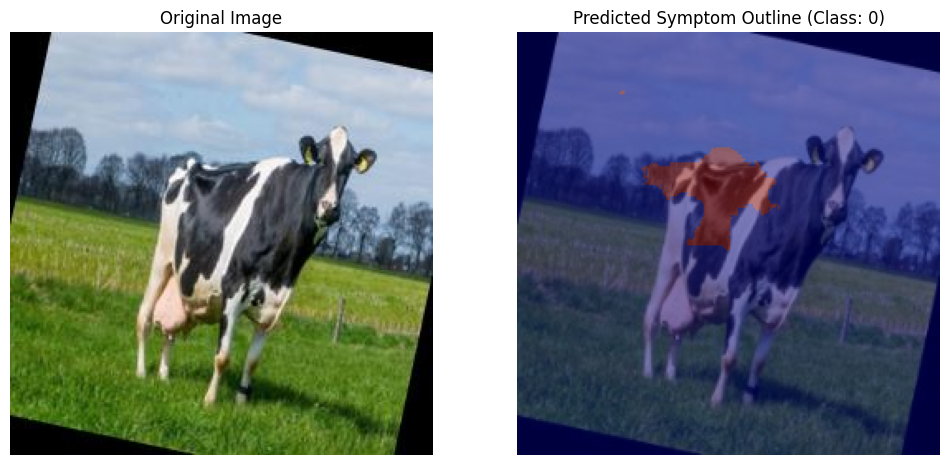

In [ ]:
import matplotlib.pyplot as plt
import random

def visualize_segmentation(model, image_paths, mask_stacks):
    # Pick a random image that has a mask
    valid_indices = [i for i, m in enumerate(mask_stacks) if len(m) > 0]
    idx = random.choice(valid_indices)

    path = image_paths[idx]
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_input = cv2.resize(img_rgb, (224, 224)) / 255.0

    # Predict
    cls_pred, mask_pred = model.predict(np.expand_dims(img_input, axis=0))

    # Process mask
    mask = mask_pred[0, :, :, 0]
    mask_binary = (mask > 0.5).astype(np.uint8)

    # Plotting
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_input)
    plt.imshow(mask_binary, alpha=0.5, cmap='jet')
    plt.title(f"Predicted Symptom Outline (Class: {np.argmax(cls_pred[0])})")
    plt.axis('off')

    plt.show()

# Visualize a prediction
visualize_segmentation(segmentation_model, all_seg_images, all_seg_masks)

### 13. Evaluate Mask Accuracy (Mean IoU)
This cell calculates the Intersection over Union (IoU) for a set of samples to quantify the segmentation performance.

In [ ]:
# Run evaluation on the refined model
print("Evaluating refined model...")
miou_result_refined = evaluate_mean_iou(segmentation_model, all_seg_images, all_seg_masks, num_samples=100)

# Compare with previous result if it exists
if 'miou_result' in globals():
    improvement = miou_result_refined - miou_result
    print(f"\nImprovement in mIoU: {improvement:+.4f}")

Evaluating refined model...
Evaluated on 100 samples.
Mean Intersection over Union (mIoU): 0.4078

Improvement in mIoU: +0.1098


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_mask_rcnn_head(num_classes):
    base = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    x = base.output
    cls_branch = layers.GlobalAveragePooling2D()(x)
    cls_branch = layers.Dense(256, activation='relu')(cls_branch)
    cls_out = layers.Dense(num_classes, activation='softmax', name='class_output')(cls_branch)
    mask_branch = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same', activation='relu')(x)
    mask_branch = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same', activation='relu')(mask_branch)
    mask_branch = layers.Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same', activation='relu')(mask_branch)
    mask_branch = layers.Conv2DTranspose(16, (4, 4), strides=(2, 2), padding='same', activation='relu')(mask_branch)
    mask_out = layers.Conv2DTranspose(1, (4, 4), strides=(2, 2), padding='same', activation='sigmoid', name='mask_output')(mask_branch)
    model = models.Model(inputs=base.input, outputs=[cls_out, mask_out])
    return model

segmentation_model = build_mask_rcnn_head(num_classes=8)
print(f'Model Input Shape: {segmentation_model.input_shape}')

Model Input Shape: (None, 224, 224, 3)
